# Wildlife AI Dataset Preview\n
This notebook previews class distribution and visualizes original vs augmented images for the wildlife classification dataset.

In [2]:
from pathlib import Path
from collections import Counter
import random

import matplotlib.pyplot as plt
from PIL import Image

DATA_TRAIN = Path('../data/train')
VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
random.seed(42)

In [4]:
def get_distribution(root: Path):
    dist = Counter()
    if not root.exists():
        return dist

    for class_dir in sorted([d for d in root.iterdir() if d.is_dir()]):
        count = sum(1 for p in class_dir.iterdir() if p.is_file() and p.suffix.lower() in VALID_EXT)
        dist[class_dir.name] = count
    return dist

dist = get_distribution(DATA_TRAIN)
dist

Counter({'dog': 3890,
         'horse': 2098,
         'butterfly': 1689,
         'cat': 1334,
         'elephant': 1156})

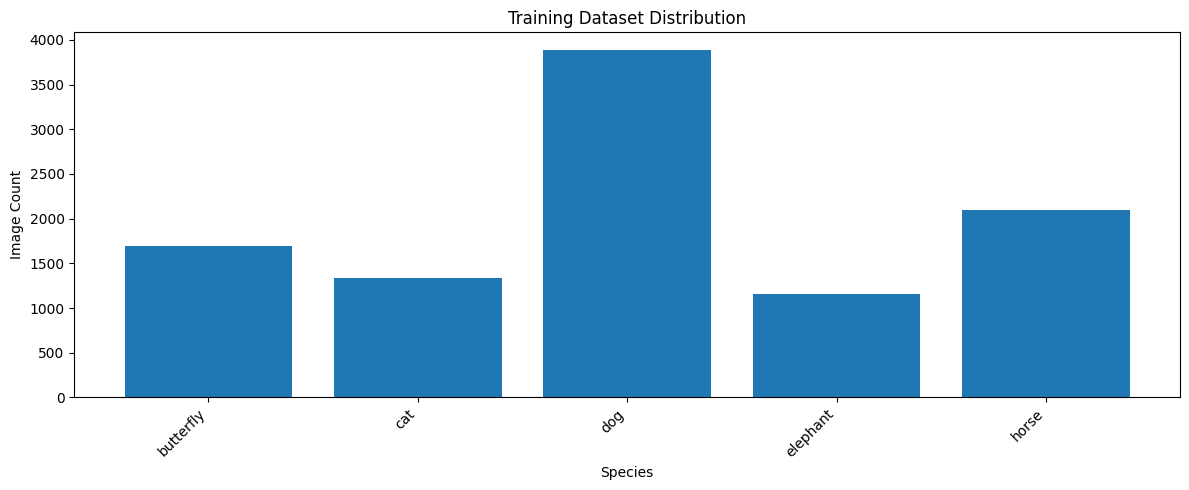

In [5]:
if not dist:
    print('No training data found in ../data/train')
else:
    labels = list(dist.keys())
    values = list(dist.values())

    plt.figure(figsize=(12, 5))
    plt.bar(labels, values)
    plt.title('Training Dataset Distribution')
    plt.xlabel('Species')
    plt.ylabel('Image Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [6]:
def show_samples(root: Path, max_classes=4):
    class_dirs = [d for d in sorted(root.iterdir()) if d.is_dir()]
    class_dirs = class_dirs[:max_classes]

    fig, axes = plt.subplots(len(class_dirs), 2, figsize=(8, 3 * len(class_dirs)))
    if len(class_dirs) == 1:
        axes = [axes]

    for i, class_dir in enumerate(class_dirs):
        originals = [p for p in class_dir.iterdir() if '_aug_' not in p.stem and p.suffix.lower() in VALID_EXT]
        augments = [p for p in class_dir.iterdir() if '_aug_' in p.stem and p.suffix.lower() in VALID_EXT]

        if originals:
            img = Image.open(random.choice(originals)).convert('RGB')
            axes[i][0].imshow(img)
            axes[i][0].set_title(f'{class_dir.name} - original')
        else:
            axes[i][0].text(0.5, 0.5, 'No original image', ha='center', va='center')

        if augments:
            img = Image.open(random.choice(augments)).convert('RGB')
            axes[i][1].imshow(img)
            axes[i][1].set_title(f'{class_dir.name} - augmented')
        else:
            axes[i][1].text(0.5, 0.5, 'No augmented image', ha='center', va='center')

        axes[i][0].axis('off')
        axes[i][1].axis('off')

    plt.tight_layout()
    plt.show()

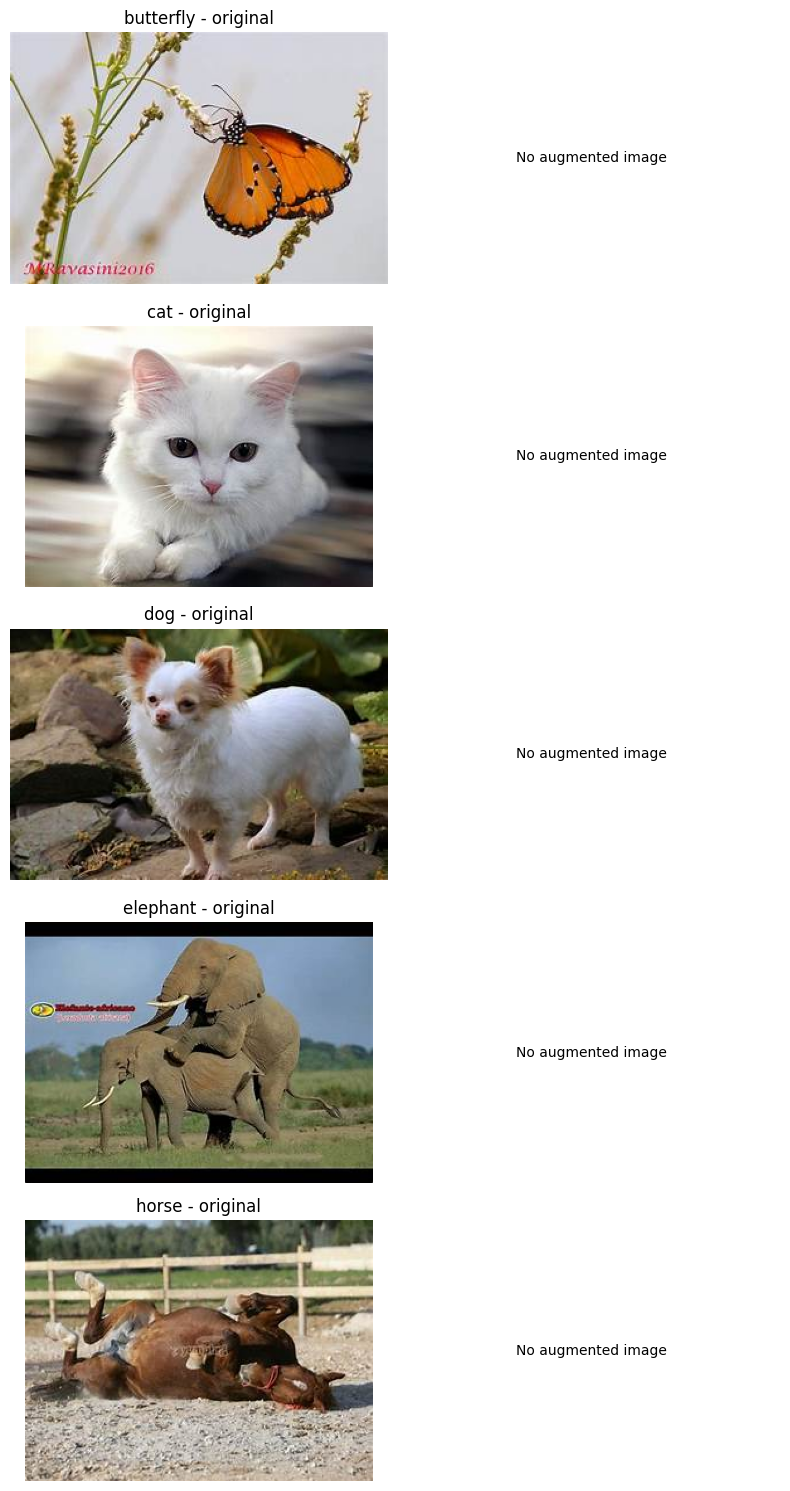

In [7]:
if DATA_TRAIN.exists():
    show_samples(DATA_TRAIN, max_classes=5)
else:
    print(f'No training data found at: {DATA_TRAIN}')
    print('Verify data/train folder exists with class subfolders')